In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"C:\Users\malar\OneDrive\Desktop\Data Science Projects\ab_data.csv"
df = pd.read_csv(file_path)

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
print(df.shape)
print(df['group'].value_counts())
print(df['landing_page'].value_counts())
print(df['converted'].value_counts())

(294478, 5)
group
treatment    147276
control      147202
Name: count, dtype: int64
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64
converted
0    259241
1     35237
Name: count, dtype: int64


In [4]:
#rows where group and landing page do not match
mismatches = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
    ]
mismatches.shape

(3893, 5)

In [5]:
mismatches.head()

,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0


In [6]:
#remove mismatched rows
df_clean = df.drop(mismatches.index)

df_clean.shape

(290585, 5)

In [7]:
df_clean['group'].value_counts()

group
treatment    145311
control      145274
Name: count, dtype: int64

In [8]:
df_clean['landing_page'].value_counts()

landing_page
new_page    145311
old_page    145274
Name: count, dtype: int64

## Experiment Validation and Cleaning
Before performing hypothesis testing, the experiment setup was validated to ensure users were exposed to the correct landing page for their assigned group. Sessions with mismatched group and landing page assignments were removed to prevent contamination of the treatment effect.

In [10]:
conversion_rates = (
    df_clean
    .groupby('group')['converted']
    .mean()
)

conversion_rates

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

## Conversion Rates by Experiment Group
After validating and cleaning the experiment data, conversion rates were calculated for control and treatment groups to assess the initial performance between the old and new landing pages.

## Hypothesis Definition

- **Null Hypothesis:** The conversion rate of the new landing page is equal to the conversion rate of the old landing page
- **Alternative Hypothesis:** The conversion rate of the new landing page is different from the conversion rate of the old landing page

In [13]:
from statsmodels.stats.proportion import proportions_ztest

# successes (conversions)
successes = df_clean.groupby('group')['converted'].sum()

# total observations
n_obs = df_clean.groupby('group')['converted'].count()

# run two-proportion z-test
z_stat, p_value = proportions_ztest(
    count=[successes['treatment'], successes['control']],
    nobs=[n_obs['treatment'], n_obs['control']]
)

z_stat, p_value

(-1.3116075339133115, 0.18965258971881804)

## Statistical Results and Decision

A two-proportion z-test was conducted to compare conversion rates between the control and treatment groups. The test produced a p-value of 0.19, which exceeds the 0.05 significance threshold.

As a result, we fail to reject the null hypothesis. The experiment does not provide statistically significant evidence that the new landing page improves conversion rates. Based on this analysis, the new page should not be rolled out at this time.

In [15]:
conversion_plot = (
    df_clean
    .groupby('group')['converted']
    .mean()
    .reset_index()
)
conversion_plot

,group,converted
0,control,0.120386
1,treatment,0.118807


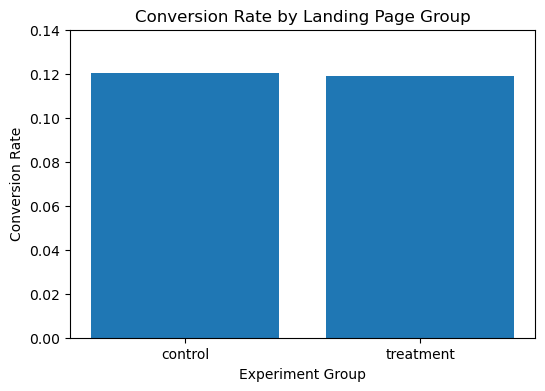

In [31]:
plt.figure(figsize=(6,4))
plt.bar(
    conversion_plot['group'],
    conversion_plot['converted']
)

plt.ylabel('Conversion Rate')
plt.xlabel('Experiment Group')
plt.title('Conversion Rate by Landing Page Group')
plt.ylim(0, 0.14)

plt.show()

## Conversion Rate Comparison

The bar chart shows a small difference in conversion rates between the control and treatment groups, with the control group slightly outperforming the
treatment group. However, this observed difference is minimal and, as confirmed by statistical testing, is not statistically significant.

## Limitations and Next Steps

This analysis evaluates the overall impact of a new landing page on conversion rate but does not account for potential differences across user segments such as device type, geography, or visit timing. Additionally, the analysis focuses solely on conversion outcomes and does not consider downstream metrics such as revenue or user retention. Future experiments could explore segmented A/B tests, alternative landing page designs, or multivariate testing approaches to identify targeted improvements for specific user groups.